# 01. Подготовка данных — D4v2 FAQ Architecture Experiment

**Цель**: подготовить KB chunks и eval set для эксперимента.

**Шаги**:
1. Загрузка и chunking KB (clinic + doctors + prices) → `chunks.json`
2. Измерение размера KB в токенах
3. Генерация seed-запросов из таксономии (6 категорий вкл. pricing)
4. LLM-генерация вариаций через `x-ai/grok-4.1-fast` (роль пациента)
5. Аннотации + reference answers (через `config.judge.model`)
6. Дедупликация + финализация → `eval_set.yaml`

**Артефакты**: `data/kb/chunks.json`, `data/eval_set_raw.yaml`, `data/eval_set.yaml`

In [1]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

KB_DIR = Path('../data/kb')
CONFIGS_DIR = Path('../configs')
DATA_DIR = Path('../data')

## 1. Загрузка и логический chunking KB

In [2]:
from d4.pipeline.chunker import load_and_chunk_kb, save_chunks, print_chunk_summary

chunks = load_and_chunk_kb(KB_DIR)
print_chunk_summary(chunks)

# Сохраняем chunks
save_chunks(chunks, KB_DIR / 'chunks.json')
print(f'\nСохранено: {KB_DIR / "chunks.json"}')

Всего chunks: 55
  clinic_info: 14 секций
  price_list: 19 категорий
  doctors: 22 врачей
  общий размер: 10407 токенов

Сохранено: ../data/kb/chunks.json


## 2. Измерение размера KB в токенах

In [3]:
import pandas as pd

# Сводка по chunks
df_chunks = pd.DataFrame([c.model_dump() for c in chunks])
print(f'Всего chunks: {len(df_chunks)}')
print(f'Общий размер: {df_chunks["token_count"].sum()} токенов\n')

# По типам
print('По source_type:')
print(df_chunks.groupby('source_type')['token_count'].agg(['count', 'sum', 'mean']).round(1))
print()

# По entity_type
print('По entity_type:')
print(df_chunks.groupby('entity_type')['token_count'].agg(['count', 'sum', 'mean']).round(1))

Всего chunks: 55
Общий размер: 10407 токенов

По source_type:
             count   sum   mean
source_type                    
clinic_info     14   637   45.5
doctors         22  4197  190.8
price_list      19  5573  293.3

По entity_type:
                count   sum   mean
entity_type                       
doctor             22  4197  190.8
faq_section        14   637   45.5
price_category     19  5573  293.3


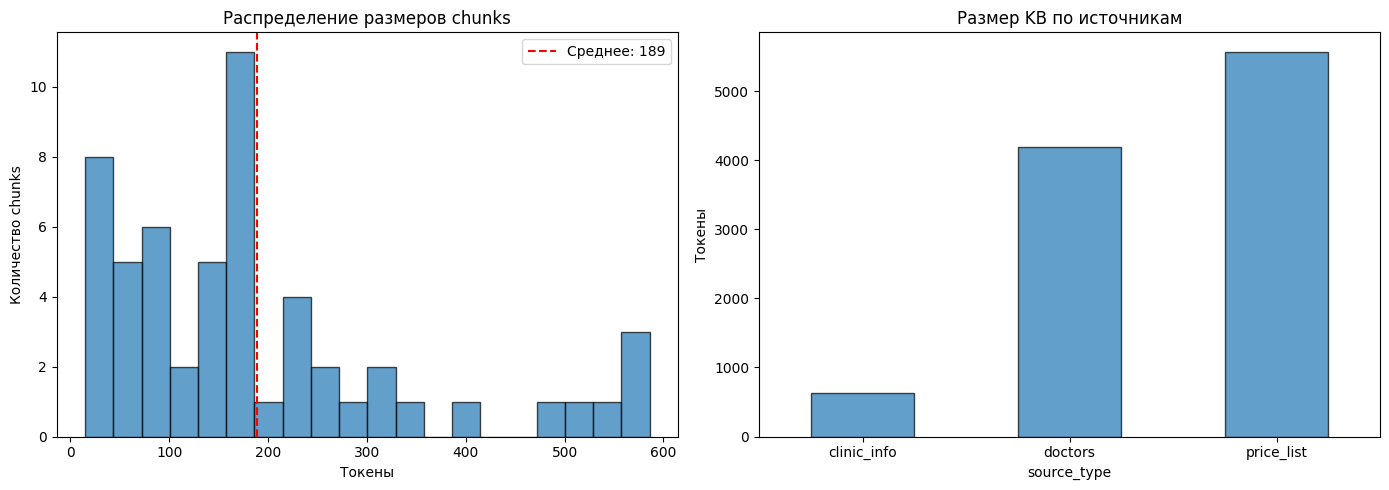

In [4]:
# Распределение размеров chunks
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма размеров
axes[0].hist(df_chunks['token_count'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Токены')
axes[0].set_ylabel('Количество chunks')
axes[0].set_title('Распределение размеров chunks')
axes[0].axvline(df_chunks['token_count'].mean(), color='red', linestyle='--', label=f'Среднее: {df_chunks["token_count"].mean():.0f}')
axes[0].legend()

# По source_type
df_chunks.groupby('source_type')['token_count'].sum().plot.bar(ax=axes[1], edgecolor='black', alpha=0.7)
axes[1].set_title('Размер KB по источникам')
axes[1].set_ylabel('Токены')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/kb_chunk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Генерация seed-запросов из таксономии

In [5]:
from d4.data_gen.query_generator import (
    load_taxonomy,
    generate_sample_templates,
    count_target_queries,
    save_eval_set,
    print_eval_set_summary,
)

taxonomy = load_taxonomy(CONFIGS_DIR / 'taxonomy.yaml')
targets = count_target_queries(taxonomy)
print(f'Целевое количество по таксономии: {sum(targets.values())} запросов')
print(f'Количество подтипов: {len(targets)}\n')

# Генерация seed-примеров
seed_samples = generate_sample_templates(taxonomy)
print_eval_set_summary(seed_samples)

Целевое количество по таксономии: 145 запросов
Количество подтипов: 27

Eval set: 91 запросов
  answerable: 78, unanswerable: 13
  по категориям:
    complaint_routing: 17
    doctor_lookup: 16
    factoid: 23
    out_of_scope: 13
    pricing: 13
    reasoning: 9


In [6]:
# Сохраняем как eval_set_raw (до ручной доработки)
save_eval_set(seed_samples, DATA_DIR / 'eval_set_raw.yaml')
print(f'Сохранено: {DATA_DIR / "eval_set_raw.yaml"}')
print(f'Seed-примеров: {len(seed_samples)}')
print(f'\nСледующий шаг: дополнить LLM-генерацией до 150 запросов,')
print(f'добавить ручные формулировки (≥30-40%), экспертная разметка.')

Сохранено: ../data/eval_set_raw.yaml
Seed-примеров: 91

Следующий шаг: дополнить LLM-генерацией до 150 запросов,
добавить ручные формулировки (≥30-40%), экспертная разметка.


## 4. Расширение eval set — LLM-генерация вариаций

Для каждого seed-запроса генерируем 3 вариации (casual, typo, indirect) через LLM.
Цель: 49 seeds × 3 вариации ≈ 147 + 49 seeds = ~196, после дедупликации → ~150+.

In [7]:
import os
from d4.config import load_config
from d4.data_gen.query_generator import generate_llm_variations

config = load_config(CONFIGS_DIR / 'experiment.yaml')
api_key = os.environ.get('OPENROUTER_API_KEY', '')
assert api_key, "Установите OPENROUTER_API_KEY"

# Модель для вариаций: Grok — более человечный стиль диалога
VARIATION_MODEL = "x-ai/grok-4.1-fast"

# Генерация 3 вариаций на каждый seed (casual, typo, indirect)
variations = generate_llm_variations(
    seed_samples=seed_samples,
    api_url=config.llm.api_url,
    api_key=api_key,
    model=VARIATION_MODEL,
    temperature=0.7,
    max_tokens=512,
    max_workers=config.rate_limit.max_workers,
)

# Объединяем seeds + вариации
all_samples = list(seed_samples) + variations
print(f"\nОбъединённый eval set: {len(all_samples)} ({len(seed_samples)} seeds + {len(variations)} вариаций)")

  генерация вариаций: 91 seed-запросов, 8 потоков
  вариации: 10/91 (17.2s)
  вариации: 20/91 (31.2s)
  вариации: 30/91 (45.1s)
  вариации: 40/91 (61.6s)


Отброшена вариация с не-русскими символами: кривыe зубы что делать


  вариации: 50/91 (73.0s)
  вариации: 60/91 (84.1s)
  вариации: 70/91 (95.2s)
  вариации: 80/91 (110.7s)


Не удалось распарсить вариации: [
  {"query": "Погода?", "style": "casual"},
  {"query": "какая погода сегодня скока градусов", "style


  вариации: 90/91 (149.0s)
  вариации готово: 269 из 91 seeds за 209.3s

Объединённый eval set: 360 (91 seeds + 269 вариаций)


## 5. Метаданные и reference answers

**Шаг 5a**: `populate_annotations` — deterministic metadata (expected_doctor, out_of_scope refusal).

**Шаг 5b**: `generate_reference_answers` — expected_answer для answerable samples через reference LLM.

Двухшаговый подход устраняет циркулярность: эталонные ответы генерируются
независимой моделью (judge config), а не захардкожены автором эксперимента.

In [8]:
import yaml
from d4.data_gen.query_generator import (
    populate_annotations,
    apply_gold_chunk_ids,
    generate_reference_answers,
)
from d4.evaluation.gold_map import build_gold_map
from d4.pipeline.factory import get_reference_llm_config

# Загружаем doctors для аннотаций
with open(KB_DIR / 'doctors.yaml', encoding='utf-8') as f:
    doctors_data = yaml.safe_load(f)
doctors = doctors_data['doctors']

# --- Шаг 5a: deterministic metadata (expected_doctor, out_of_scope) ---
all_samples = populate_annotations(all_samples, doctors)

# --- Шаг 5b: reference answers через LLM (устранение циркулярности) ---
# config и api_key уже загружены в cell 11 (generate_llm_variations)
ref_config = get_reference_llm_config(config, api_key)

# KB контекст: [chunk_id] title\ncontent — ID важен для трассировки
kb_text = "\n\n---\n\n".join(
    f"[{chunk.id}] {chunk.title}\n{chunk.content}" for chunk in chunks
)
all_samples = generate_reference_answers(all_samples, kb_text, **ref_config)

# Проверка покрытия
answered = sum(1 for s in all_samples if s.expected_answer)
print(f"  expected_answer заполнен: {answered}/{len(all_samples)}")

# --- Gold chunk IDs ---
gold_map = build_gold_map(all_samples, doctors)
all_samples = apply_gold_chunk_ids(all_samples, gold_map)

  метаданные: expected_answer (out_of_scope) у 49/360
  метаданные: expected_doctor у 47/360
  reference answers: 311 сэмплов, 8 потоков
  reference answers: 10/311 (10.7s)
  reference answers: 20/311 (15.4s)
  reference answers: 30/311 (21.2s)
  reference answers: 40/311 (30.1s)
  reference answers: 50/311 (38.7s)
  reference answers: 60/311 (45.0s)
  reference answers: 70/311 (54.3s)
  reference answers: 80/311 (61.1s)
  reference answers: 90/311 (69.8s)
  reference answers: 100/311 (77.3s)
  reference answers: 110/311 (84.0s)
  reference answers: 120/311 (90.9s)
  reference answers: 130/311 (96.0s)
  reference answers: 140/311 (101.2s)
  reference answers: 150/311 (107.8s)
  reference answers: 160/311 (116.1s)
  reference answers: 170/311 (122.8s)
  reference answers: 180/311 (130.3s)
  reference answers: 190/311 (140.6s)
  reference answers: 200/311 (149.8s)
  reference answers: 210/311 (160.3s)
  reference answers: 220/311 (169.0s)
  reference answers: 230/311 (178.8s)
  reference

## 6. Дедупликация и финализация

Удаляем дубликаты по cosine similarity (порог 0.85), назначаем уникальные ID.

In [9]:
from d4.data_gen.query_generator import (
    deduplicate_queries,
    assign_unique_ids,
    save_eval_set,
)

# Дедупликация по embedding similarity
all_samples = deduplicate_queries(
    all_samples,
    model_name=config.embedding.model,
    threshold=0.85,
)
print(f"После дедупликации: {len(all_samples)} сэмплов")

# Уникальные ID
all_samples = assign_unique_ids(all_samples)

# Перестраиваем gold_map после назначения новых ID
gold_map = build_gold_map(all_samples, doctors)
all_samples = apply_gold_chunk_ids(all_samples, gold_map)

# Сохранение финального eval set
save_eval_set(all_samples, DATA_DIR / 'eval_set.yaml')
print(f"Сохранено: {DATA_DIR / 'eval_set.yaml'}")
print(f"Финальный eval set: {len(all_samples)} сэмплов")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Дедупликация: удалено 98 дубликатов (threshold=0.85)
После дедупликации: 262 сэмплов
  gold_chunk_ids: заполнено у 208/262 сэмплов
Сохранено: ../data/eval_set.yaml
Финальный eval set: 262 сэмплов


## 7. Сводка по финальному eval set

In [10]:
df_eval = pd.DataFrame([s.model_dump() for s in all_samples])

# По категориям
print('Распределение по категориям:')
print(df_eval['category'].value_counts())
print()

# По answerable
print(f'Answerable: {df_eval["answerable"].sum()} / {len(df_eval)}')
print(f'Unanswerable: {(~df_eval["answerable"]).sum()} / {len(df_eval)}')
print()

# Покрытие аннотаций
print(f'expected_answer заполнен: {df_eval["expected_answer"].apply(bool).sum()} / {len(df_eval)}')
print(f'expected_doctor заполнен: {df_eval["expected_doctor"].notna().sum()} / {len(df_eval)}')
print(f'gold_chunk_ids заполнен: {df_eval["gold_chunk_ids"].apply(bool).sum()} / {len(df_eval)}')

Распределение по категориям:
category
factoid              67
doctor_lookup        47
complaint_routing    47
pricing              39
out_of_scope         37
reasoning            25
Name: count, dtype: int64

Answerable: 225 / 262
Unanswerable: 37 / 262

expected_answer заполнен: 262 / 262
expected_doctor заполнен: 34 / 262
gold_chunk_ids заполнен: 208 / 262


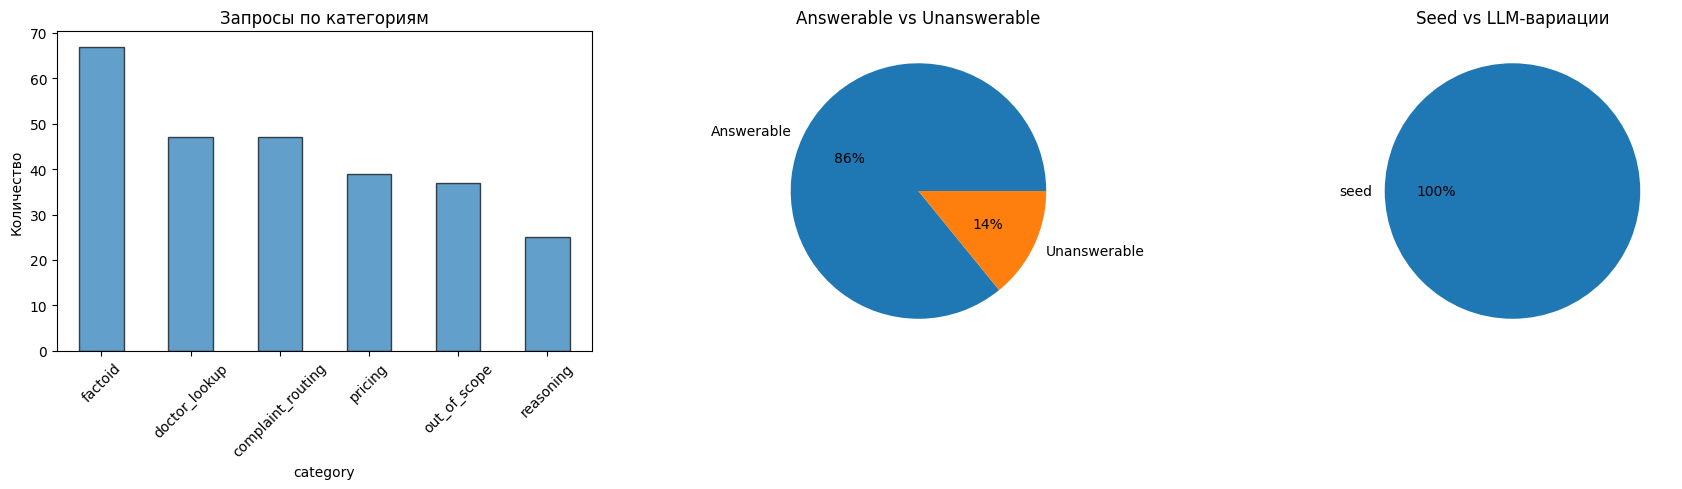

In [11]:
# Визуализация финального распределения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_eval['category'].value_counts().plot.bar(ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_title('Запросы по категориям')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

df_eval['answerable'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.0f%%', labels=['Answerable', 'Unanswerable'],
)
axes[1].set_title('Answerable vs Unanswerable')
axes[1].set_ylabel('')

# Источник сэмплов: seed vs llm_variation
source_counts = df_eval['notes'].apply(
    lambda n: 'seed' if 'seed' in str(n) else 'llm_variation'
).value_counts()
source_counts.plot.pie(ax=axes[2], autopct='%1.0f%%')
axes[2].set_title('Seed vs LLM-вариации')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/figures/eval_set_distribution.png', dpi=150, bbox_inches='tight')
plt.show()